In [1]:
from ansatze import Ansatz

a = Ansatz(40)
print(a.param_count())  # should be 40

a.add_layer()
print(a.param_count())  # should be 196

a.add_layer()
print(a.param_count())  # should be 352

# also check gates list has no index errors
gates = a.get_gates(a.params)
print(f"Total gates: {len(gates)}")

40
196
352
Total gates: 508


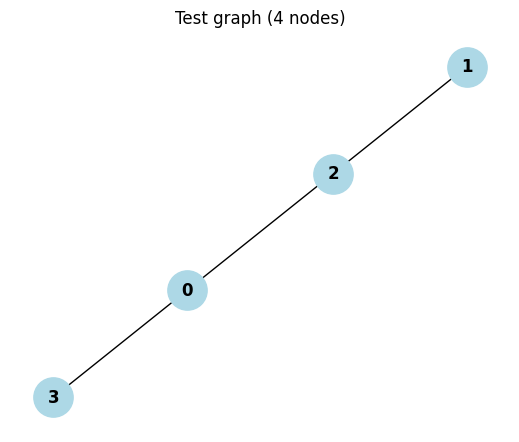

n_qubits: 4
n_terms: 32
best known modularity: 0.1666666666666667
param count: 4
energy: -0.059956754273667236
approximation ratio: -0.3597405256420033
sampled energy: -0.06147222222222221
param count after layer 1: 16
energy after adding layer (should be same as before): -0.05995675427366692


In [4]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from community_detection import CommunityDetection
from ansatze import Ansatz
from simulator import QuimbSimulator

# small graph, easy to verify
G = nx.gnp_random_graph(4, 0.5, seed=42)

# plot the graph
plt.figure(figsize=(5, 4))
nx.draw(G, with_labels=True, node_color='lightblue', 
        node_size=800, font_size=12, font_weight='bold')
plt.title("Test graph (4 nodes)")
plt.show()

k = 2
problem = CommunityDetection(G, k)
print(f"n_qubits: {problem.n_qubits}")
print(f"n_terms: {len(problem.terms)}")
print(f"best known modularity: {problem.best_known_value()}")

ansatz = Ansatz(problem.n_qubits)
print(f"param count: {ansatz.param_count()}")

sim = QuimbSimulator()

energy = sim.expectation(ansatz.params, ansatz, problem)
print(f"energy: {energy}")
print(f"approximation ratio: {problem.approximation_ratio(energy, problem.best_known_value())}")

energy_sampled = sim.sample_expectation(ansatz.params, ansatz, problem, n_samples=2000)
print(f"sampled energy: {energy_sampled}")


# check that adding layers and recomputing works
ansatz.add_layer()
print(f"param count after layer 1: {ansatz.param_count()}")  # should be 4 + 156? 
# wait, n=4 so: 4 + 4*4-4 = 4 + 12 = 16
energy2 = sim.expectation(ansatz.params, ansatz, problem)
print(f"energy after adding layer (should be same as before): {energy2}")

In [5]:
from optimizer import COBYLA, SMO

# setup
G = nx.gnp_random_graph(4, 0.5, seed=42)
k = 2
problem = CommunityDetection(G, k)
ansatz = Ansatz(problem.n_qubits)
sim = QuimbSimulator()

# cost function — exact expectation
cost_fn = lambda p: sim.expectation(p, ansatz, problem)

best_known = problem.best_known_value()
print(f"best known modularity: {best_known}")
print(f"initial energy: {cost_fn(ansatz.params):.4f}")
print(f"initial approx ratio: {problem.approximation_ratio(cost_fn(ansatz.params), best_known):.4f}")

# test COBYLA
print("\n--- COBYLA ---")
ansatz_cobyla = Ansatz(problem.n_qubits)  # fresh random init
cost_fn_cobyla = lambda p: sim.expectation(p, ansatz_cobyla, problem)
best_params_cobyla, best_energy_cobyla = COBYLA(max_iter=500, rhobeg=1.0).optimise(
    ansatz_cobyla.params, cost_fn_cobyla
)
print(f"best energy: {best_energy_cobyla:.4f}")
print(f"approx ratio: {problem.approximation_ratio(best_energy_cobyla, best_known):.4f}")

# test SMO
print("\n--- SMO ---")
ansatz_smo = Ansatz(problem.n_qubits)  # fresh random init
cost_fn_smo = lambda p: sim.expectation(p, ansatz_smo, problem)
best_params_smo, best_energy_smo = SMO(max_iter=500).optimise(
    ansatz_smo.params, cost_fn_smo
)
print(f"best energy: {best_energy_smo:.4f}")
print(f"approx ratio: {problem.approximation_ratio(best_energy_smo, best_known):.4f}")

best known modularity: 0.1666666666666667
initial energy: 0.2202
initial approx ratio: 1.3210

--- COBYLA ---
best energy: 0.5000
approx ratio: 3.0000

--- SMO ---
best energy: 0.2939
approx ratio: 1.7637
